# 3.2 — Абляции, метрики по группам и out-of-distribution тесты

**Папка 3, подноутбук 2.** Анализ устойчивости и вклада компонентов: метрики по типам
грунта и режимам нагружения, абляции DPI-Flow и EVT-NeuralSSM, OOD-тесты (экстраполяция
«короткий → длинный горизонт» и удержанный регион слабых грунтов). Все рисунки и таблицы
— на английском.

## Окружение, данные и модели

In [1]:
import sys
from pathlib import Path


def find_repo_root(start: Path) -> Path:
    """Найти корень репозитория по наличию pyproject.toml вверх по дереву."""
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists():
            return candidate
    return start


REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / "src"))

import numpy as np
import pandas as pd
from IPython.display import display

from liquefaction_ai.viz import register_theme

register_theme()

# Если True — все фигуры сохраняются в results/figs (.html и .png)
SAVE_FIGS = True
DATA_DIR = REPO_ROOT / "data" / "demo_run"
MODELS_DIR = REPO_ROOT / "models"

import torch

from liquefaction_ai import load_population_artifact, prepare_benchmark_dataset
from liquefaction_ai.training import load_model_metadata, load_weights_into
from liquefaction_ai.models import (DPIFlow, EVTNeuralSSM, GRUBaseline, LSTMBaseline, RiskMLP, TCNBaseline, TransformerBaseline, FTTransformer,
                                    PINNBaseline, DeepStateBaseline, RealNVPFlow, NeuralSplineFlow,
                                    NeuralODENoPhysics, FlowNoODE, DPIEvtNet)
from liquefaction_ai.evaluation import collect_outputs, compute_metrics, english_metric_table

CLASS_REGISTRY = {"RiskMLP": RiskMLP, "GRUBaseline": GRUBaseline, "TCNBaseline": TCNBaseline, "LSTMBaseline": LSTMBaseline, "TransformerBaseline": TransformerBaseline, "FTTransformer": FTTransformer, "PINNBaseline": PINNBaseline, "DeepStateBaseline": DeepStateBaseline, "RealNVPFlow": RealNVPFlow, "NeuralSplineFlow": NeuralSplineFlow,
                  "DPIFlow": DPIFlow, "EVTNeuralSSM": EVTNeuralSSM, "DPIEvtNet": DPIEvtNet}
MODEL_NAMES = ["mlp_risk", "gru", "tcn", "lstm", "transformer", "ft_transformer", "pinn", "deepstate", "realnvp", "nsf", "dpi_flow", "evt_ssm", "dpi_evt"]

population, config = load_population_artifact(DATA_DIR)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
benchmark = prepare_benchmark_dataset(population, config, device)
test = benchmark["test"]


def load_trained(name):
    """Восстановить модель по сохранённым гиперпараметрам и весам."""
    hp, hist = load_model_metadata(MODELS_DIR, name)
    model = CLASS_REGISTRY[hp["model_type"]](**hp["model_kwargs"])
    load_weights_into(model, MODELS_DIR, name, device)
    return model, hp, hist
from liquefaction_ai.evaluation import (filter_split, grouped_metrics, is_holdout_region,
                                        run_quick_experiment, subsample_split)
from liquefaction_ai.constants import LOAD_DISPLAY_NAMES_EN, SOIL_DISPLAY_NAMES_EN
from liquefaction_ai.viz import bar, grouped_bar

## Metrics by soil type and loading regime (DPI-Flow)

,soil_en,N samples,Liquefaction rate,Mean predicted risk,n_nliq_observed,Mean |ΔN_liq| (cycles),Mean log-error N_liq,Mean trajectory RMSE,Mean interval width,Physics violations,AUROC
2,Loam,41,0.7073,0.7077,41.0,23.588900,0.1458,0.1281,0.3369,0.0,1.0
0,Clay,36,0.5000,0.4993,36.0,26.866100,0.1630,0.1444,0.3249,0.0,1.0
3,Medium sand,24,0.7500,0.7473,24.0,32.284302,0.2136,0.2673,0.3801,0.0,1.0
4,Silty sand,24,0.7500,0.7471,24.0,27.070499,0.2035,0.1270,0.3418,0.0,1.0
1,Fine sand,12,0.0000,0.0215,12.0,11.011600,0.0022,0.1285,0.3046,0.0,NaN


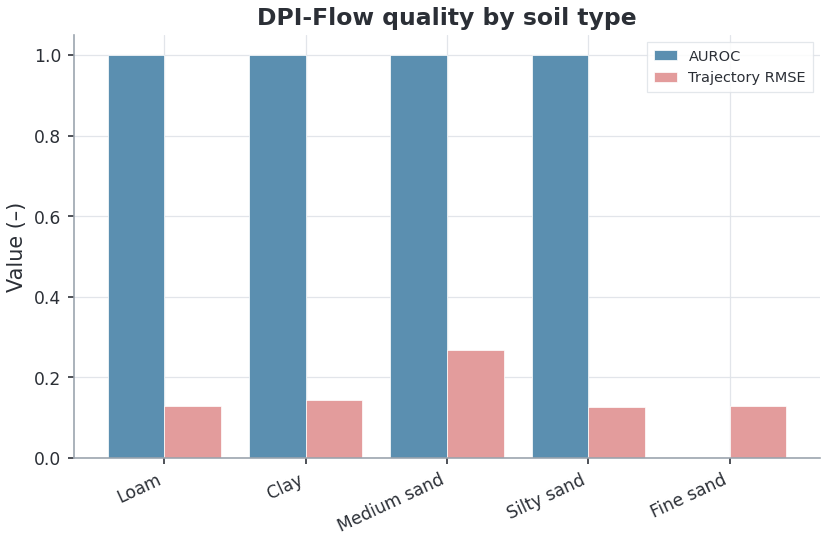

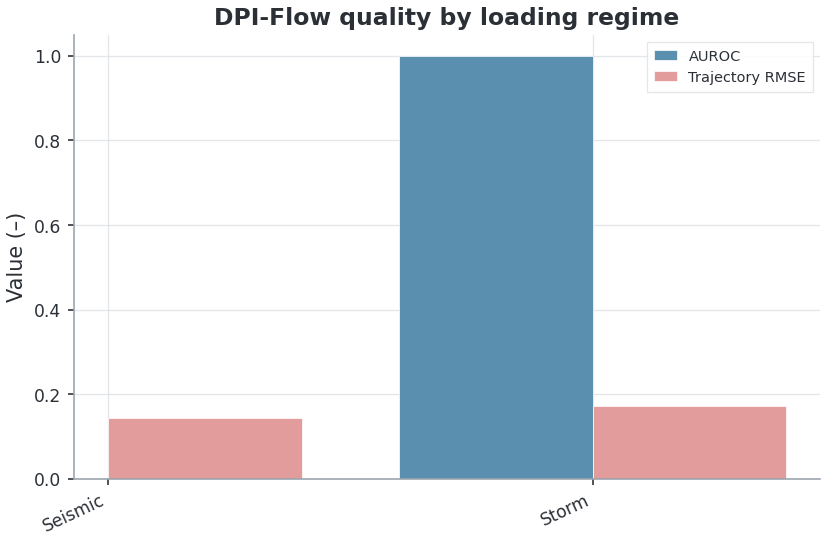

In [2]:
dpi, hp, _ = load_trained("dpi_flow")
out = collect_outputs(dpi, test, config, device)
_, sample_df = compute_metrics("DPI-Flow", out, test, config)
sample_df["soil_en"] = sample_df["soil_type"].map(SOIL_DISPLAY_NAMES_EN)
sample_df["load_en"] = sample_df["load_mode"].map(LOAD_DISPLAY_NAMES_EN)
soil_metrics = grouped_metrics(sample_df, "soil_en")
load_metrics = grouped_metrics(sample_df, "load_en")
display(english_metric_table(soil_metrics).round(4))
grouped_bar(soil_metrics["soil_en"].tolist(),
            {"AUROC": soil_metrics["AUROC"].tolist(), "Trajectory RMSE": soil_metrics["mean_traj_rmse"].tolist()},
            title="DPI-Flow quality by soil type", ylabel="Value (–)",
            save=SAVE_FIGS, fig_id="3_2_metrics_by_soil").show()
grouped_bar(load_metrics["load_en"].tolist(),
            {"AUROC": load_metrics["AUROC"].tolist(), "Trajectory RMSE": load_metrics["mean_traj_rmse"].tolist()},
            title="DPI-Flow quality by loading regime", ylabel="Value (–)",
            save=SAVE_FIGS, fig_id="3_2_metrics_by_load").show()

## Component ablations

[DPI-Flow (full)] эпоха 01 | обучение=5.9646 | валидация=-0.2573


[DPI-Flow (full)] эпоха 02 | обучение=0.7237 | валидация=-0.7550


[DPI-Flow w/o calibration] эпоха 01 | обучение=3.6433 | валидация=0.2763


[DPI-Flow w/o calibration] эпоха 02 | обучение=-0.3638 | валидация=-1.0411


[DPI-Flow w/o probabilistic head] эпоха 01 | обучение=4.6144 | валидация=-0.0309


...

[EVT w/o post-event dynamics] эпоха 01 | обучение=6.3393 | валидация=-0.0508


[EVT w/o post-event dynamics] эпоха 02 | обучение=1.6358 | валидация=-0.6721


[EVT w/o CRR damage] эпоха 01 | обучение=2.5034 | валидация=0.4678


[EVT w/o CRR damage] эпоха 02 | обучение=-0.4220 | валидация=-0.9803


,Model,Trajectory RMSE,AUROC,Brier
10,EVT w/o CRR damage,0.1421,1.0000,0.0454
7,EVT (full),0.1589,1.0000,0.0384
1,DPI-Flow w/o calibration,0.1828,1.0000,0.0334
4,ODE w/o flow,0.2116,1.0000,0.0490
0,DPI-Flow (full),0.2219,1.0000,0.0854
8,EVT w/o trigger,0.2420,1.0000,0.0550
3,DPI-Flow w/o ODE layer,0.2639,1.0000,0.0040
6,Neural ODE w/o physics,0.3196,0.9953,0.1620
5,Flow w/o ODE,0.3299,1.0000,0.0280
2,DPI-Flow w/o probabilistic head,0.4665,1.0000,0.0944


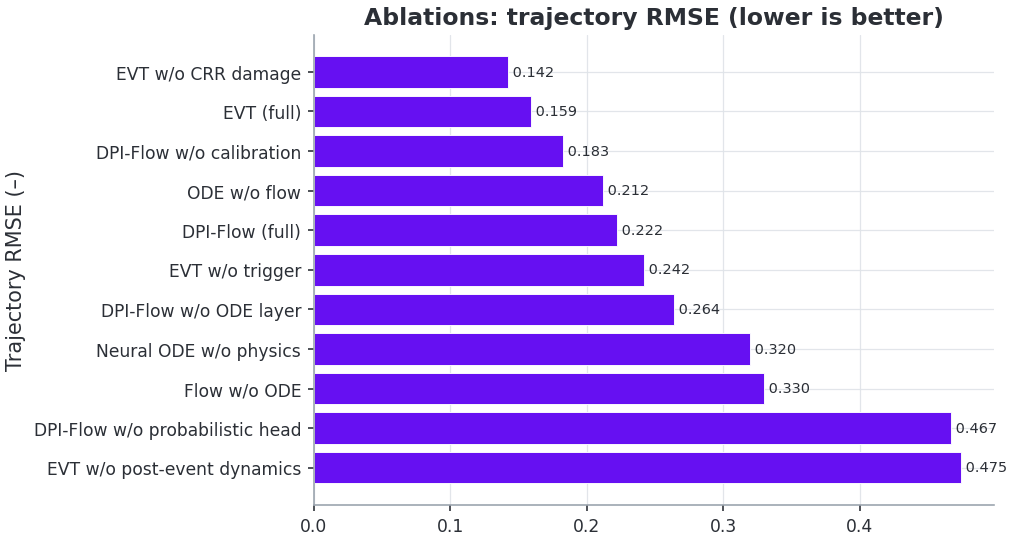

In [3]:
sub = min(config.ablation_subset, 2400)
atrain = subsample_split(benchmark["train"], int(sub * 0.7), config.seed)
aval = subsample_split(benchmark["val"], int(sub * 0.15), config.seed + 1)
atest = subsample_split(benchmark["test"], int(sub * 0.15), config.seed + 2)
sd, pdim, qd = static_dim, prefix_dim, seq_dim = (benchmark["train"]["static"].shape[1],
    benchmark["train"]["prefix_summary"].shape[1], benchmark["train"]["seq_in"].shape[-1])
mcr, sl, pl = config.max_cycle_reference, config.seq_len, config.prefix_len
ablation_specs = [
    ("DPI-Flow (full)", DPIFlow(sd, pdim, sl, pl, mcr, calibration_steps=2, use_analytical_layer=True)),
    ("DPI-Flow w/o calibration", DPIFlow(sd, pdim, sl, pl, mcr, calibration_steps=0, use_analytical_layer=True)),
    ("DPI-Flow w/o probabilistic head", DPIFlow(sd, pdim, sl, pl, mcr, probabilistic=False, calibration_steps=2)),
    ("DPI-Flow w/o ODE layer", DPIFlow(sd, pdim, sl, pl, mcr, calibration_steps=0, use_analytical_layer=False)),
    # --- покомпонентные абляции (изоляция вклада ODE / flow / физики) ---
    ("ODE w/o flow", DPIFlow(sd, pdim, sl, pl, mcr, calibration_steps=2, use_analytical_layer=True, use_flow=False)),
    ("Flow w/o ODE", FlowNoODE(sd, pdim, sl)),
    ("Neural ODE w/o physics", NeuralODENoPhysics(sd, qd)),
    ("EVT (full)", EVTNeuralSSM(sd, pdim, qd, sl, pl, mcr)),
    ("EVT w/o trigger", EVTNeuralSSM(sd, pdim, qd, sl, pl, mcr, use_trigger_head=False)),
    ("EVT w/o post-event dynamics", EVTNeuralSSM(sd, pdim, qd, sl, pl, mcr, structured_post_event=False)),
    ("EVT w/o CRR damage", EVTNeuralSSM(sd, pdim, qd, sl, pl, mcr, use_crr_damage=False)),
]
ablation_rows = [run_quick_experiment(n, m, atrain, aval, atest, epochs=config.ablation_epochs,
                                      config=config, device=device) for n, m in ablation_specs]
ablation_df = pd.DataFrame(ablation_rows).sort_values("Traj_RMSE")
display(english_metric_table(ablation_df)[["Model", "Trajectory RMSE", "AUROC", "Brier"]].round(4))
bar(ablation_df["model"], ablation_df["Traj_RMSE"], title="Ablations: trajectory RMSE (lower is better)",
    ylabel="Trajectory RMSE (–)", color="#6610f2", horizontal=True,
    save=SAVE_FIGS, fig_id="3_2_ablations_rmse").show()

## Out-of-distribution tests

[TCN] эпоха 01 | обучение=0.3435 | валидация=0.2574


[TCN] эпоха 02 | обучение=0.2582 | валидация=0.0347


[TCN] эпоха 01 | обучение=0.3903 | валидация=0.2964


[TCN] эпоха 02 | обучение=0.2939 | валидация=0.1285


[DPI-Flow] эпоха 01 | обучение=4.5490 | валидация=-0.3816


...

[EVT-NeuralSSM] эпоха 01 | обучение=2.7002 | валидация=0.1521


[EVT-NeuralSSM] эпоха 02 | обучение=-0.3960 | валидация=-1.0788


[EVT-NeuralSSM] эпоха 01 | обучение=2.7737 | валидация=0.8588


[EVT-NeuralSSM] эпоха 02 | обучение=0.1096 | валидация=-1.0082


,Model,test,Trajectory RMSE,AUROC
0,TCN,short→long,0.2392,NaN
1,TCN,held-out region,0.3929,NaN
2,DPI-Flow,short→long,0.1891,NaN
3,DPI-Flow,held-out region,0.6495,NaN
4,EVT-NeuralSSM,short→long,0.1371,NaN
5,EVT-NeuralSSM,held-out region,0.6460,NaN


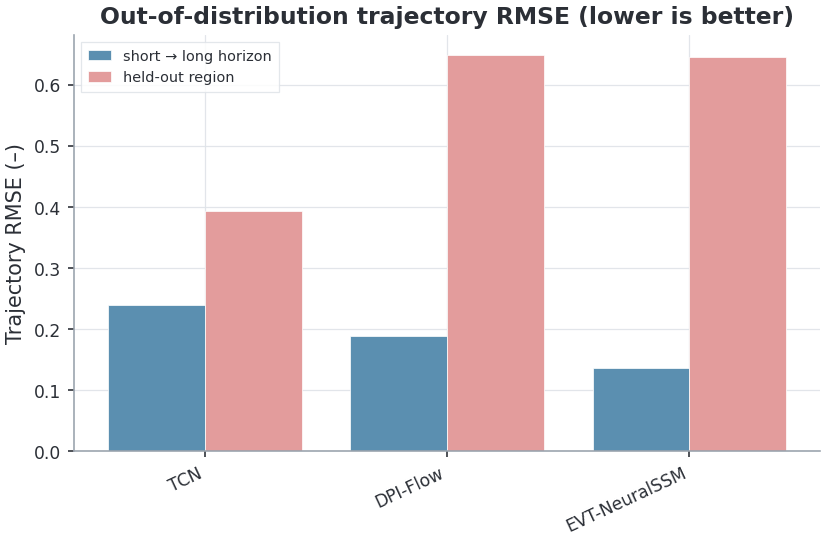

In [4]:
train_meta = benchmark["train"]["meta"]; val_meta = benchmark["val"]["meta"]; test_meta = benchmark["test"]["meta"]
short_thr = float(train_meta["N_max"].quantile(0.60)); long_thr = float(test_meta["N_max"].quantile(0.80))
short_train = filter_split(benchmark["train"], train_meta["N_max"].to_numpy() <= short_thr)
short_val = filter_split(benchmark["val"], val_meta["N_max"].to_numpy() <= short_thr)
long_test = filter_split(benchmark["test"], test_meta["N_max"].to_numpy() >= long_thr)
e_thr = float(benchmark["meta"]["e"].quantile(0.75)); vs_thr = float(benchmark["meta"]["V_s"].quantile(0.25))
region_test = filter_split(benchmark["test"], is_holdout_region(test_meta, e_thr, vs_thr))
hold_train = filter_split(benchmark["train"], ~is_holdout_region(train_meta, e_thr, vs_thr))
hold_val = filter_split(benchmark["val"], ~is_holdout_region(val_meta, e_thr, vs_thr))
short_train = subsample_split(short_train, 1100, config.seed); short_val = subsample_split(short_val, 300, config.seed + 1)
long_test = subsample_split(long_test, 700, config.seed + 2)
hold_train = subsample_split(hold_train, 1100, config.seed + 3); hold_val = subsample_split(hold_val, 300, config.seed + 4)
region_test = subsample_split(region_test, 700, config.seed + 5)

def fresh(kind):
    if kind == "tcn": return TCNBaseline(sd, qd, 96)
    if kind == "dpi": return DPIFlow(sd, pdim, sl, pl, mcr, calibration_steps=2)
    return EVTNeuralSSM(sd, pdim, qd, sl, pl, mcr)

ood_rows = []
for disp, kind in [("TCN", "tcn"), ("DPI-Flow", "dpi"), ("EVT-NeuralSSM", "evt")]:
    ood_rows.append({**run_quick_experiment(disp, fresh(kind), short_train, short_val, long_test,
                     epochs=config.ablation_epochs, config=config, device=device), "test": "short→long"})
    ood_rows.append({**run_quick_experiment(disp, fresh(kind), hold_train, hold_val, region_test,
                     epochs=config.ablation_epochs, config=config, device=device), "test": "held-out region"})
ood_df = pd.DataFrame(ood_rows)
display(english_metric_table(ood_df)[["Model", "test", "Trajectory RMSE", "AUROC"]].round(4))
sl_df = ood_df[ood_df["test"] == "short→long"]; rg_df = ood_df[ood_df["test"] == "held-out region"]
grouped_bar(sl_df["model"].tolist(),
            {"short → long horizon": sl_df["Traj_RMSE"].tolist(), "held-out region": rg_df["Traj_RMSE"].tolist()},
            title="Out-of-distribution trajectory RMSE (lower is better)", ylabel="Trajectory RMSE (–)",
            save=SAVE_FIGS, fig_id="3_2_ood_rmse").show()

## Итог

Абляции подтверждают вклад компонентов; структурированные модели устойчивее в OOD.
Дальше — **3.3 разбор кейсов**.


=== OOD по: площадка (site) ===


,object,N samples,Mean trajectory RMSE,Mean log-error N_liq,Physics violations,AUROC
0,Потенциал разжижения/333-24 Дубнинская - Plaxi...,71,0.1423,0.2736,0.0,NaN
1,Штормовое разжижение/390-24 Шаболовская -Plaxi...,66,0.1719,0.0373,0.0,1.0


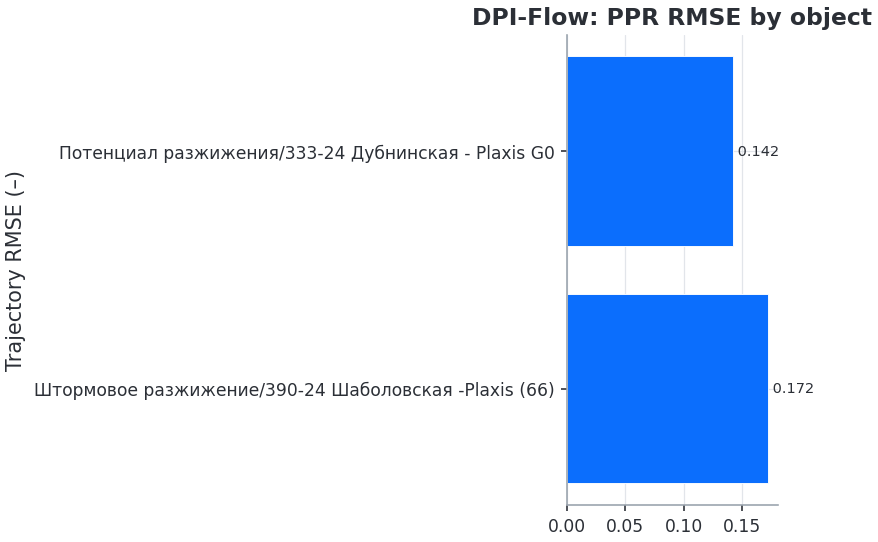


=== OOD по: тип грунта ===


,soil_en,N samples,Mean trajectory RMSE,Mean log-error N_liq,Physics violations,AUROC
2,Loam,41,0.1281,0.1458,0.0,1.0
0,Clay,36,0.1444,0.1630,0.0,1.0
3,Medium sand,24,0.2673,0.2136,0.0,1.0
4,Silty sand,24,0.1270,0.2035,0.0,1.0
1,Fine sand,12,0.1285,0.0022,0.0,NaN


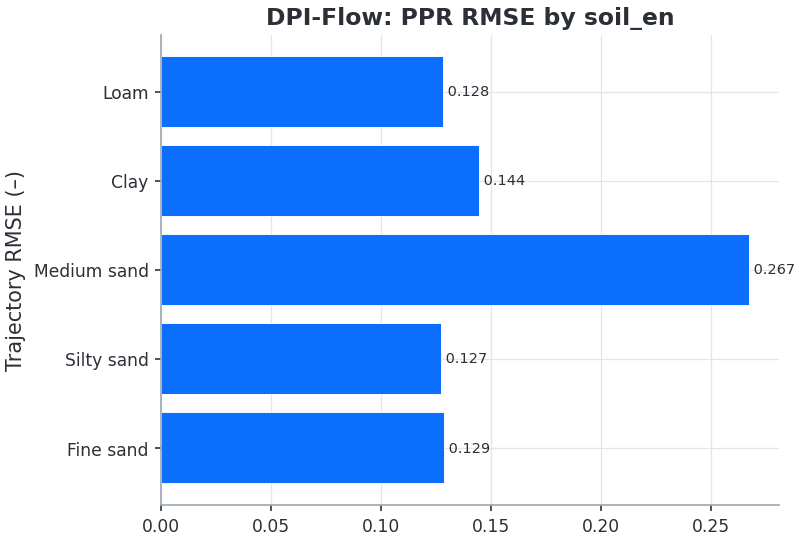


=== OOD по: диапазон CSR ===


/Users/nikita/Desktop/projects/liquefaction-ai/src/liquefaction_ai/evaluation/metrics.py:605: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sample_df.groupby(group_col)


,CSR_bin,N samples,Mean trajectory RMSE,Mean log-error N_liq,Physics violations,AUROC
0,CSR≤0.12,56,0.1256,0.0071,0.0,1.0
1,0.12–0.18,41,0.0672,0.2208,0.0,NaN
2,0.18–0.25,20,0.0817,0.3218,0.0,NaN
3,CSR>0.25,20,0.5015,0.3000,0.0,NaN


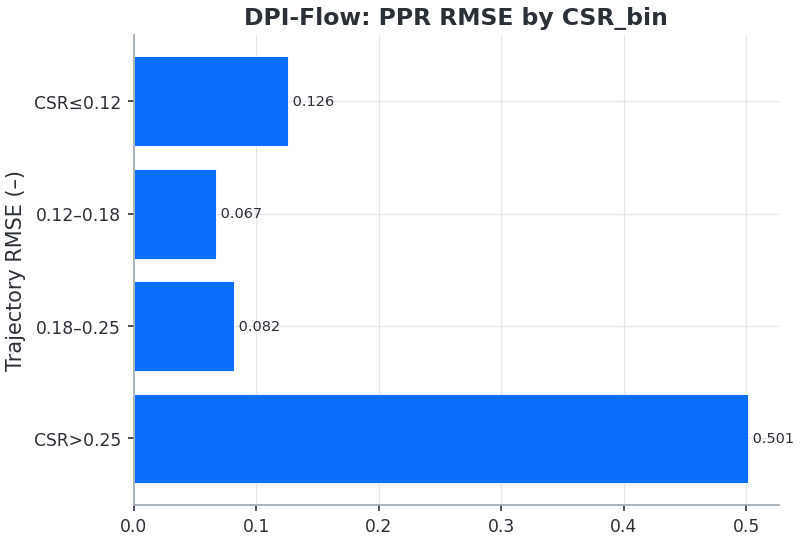

In [5]:
# === OOD-разбиение: качество по площадкам, типам грунтов и диапазонам CSR ===
# Для основной модели (DPI-Flow) считаем метрики по группам — генерализация по доменам.
from liquefaction_ai.evaluation import grouped_metrics
dpi_full, _, _ = load_trained("dpi_flow")
_out = collect_outputs(dpi_full, test, config, device)
_, sdf = compute_metrics("DPI-Flow", _out, test, config)
sdf["soil_en"] = sdf["soil_type"].map(SOIL_DISPLAY_NAMES_EN)
import numpy as np
sdf["CSR_bin"] = pd.cut(sdf["CSR_base"], [0, 0.12, 0.18, 0.25, 1.0],
                         labels=["CSR≤0.12", "0.12–0.18", "0.18–0.25", "CSR>0.25"])
_show = ["samples", "mean_traj_rmse", "mean_nliq_log_err", "physics_violation_rate", "AUROC"]
for dim, label in [("object", "площадка (site)"), ("soil_en", "тип грунта"), ("CSR_bin", "диапазон CSR")]:
    g = grouped_metrics(sdf, dim)
    print(f"\n=== OOD по: {label} ===")
    display(english_metric_table(g[[dim] + _show]).round(4))
    bar(g[dim].astype(str), g["mean_traj_rmse"], title=f"DPI-Flow: PPR RMSE by {dim}",
        ylabel="Trajectory RMSE (–)", color="#0b6efd", horizontal=True,
        save=SAVE_FIGS, fig_id=f"3_2_ood_{dim}").show()
    if dim in ("soil_en", "CSR_bin"):
        _fn = "ood_by_soil" if dim == "soil_en" else "ood_by_csr"
        g[[dim] + _show].round(4).to_csv(REPO_ROOT / "results" / "tables" / f"{_fn}.csv", index=False)